# XGBoost Prediction Model: House Price Prediction

## 1. මොකක්ද මේ XGBoost කියන්නේ? (Concept)
XGBoost (eXtreme Gradient Boosting) කියන්නේ **Decision Trees** මත පදනම් වුණු "Ensemble Learning" ක්‍රමවේදයක්. සරලවම කිව්වොත්, දුර්වල මොඩල් (Weak Learners) කිහිපයක් එකතු කරලා ඉතාම ශක්තිමත් මොඩල් එකක් නිර්මාණය කිරීම මෙතනදී සිද්ධ වෙනවා.

## 2. මූලික ගණිතමය පදනම (The Math)
XGBoost වැඩ කරන්නේ **Objective Function** එකක් minimize කරන්නයි. මෙය කොටස් දෙකකින් සමන්විතයි:

$$Obj(\theta) = L(\theta) + \Omega(\theta)$$

* **$L(\theta)$ (Loss Function):** අපේ prediction එක සහ ඇත්තම අගය අතර වෙනස (උදා: Mean Squared Error). මෙය පුළුවන් තරම් අඩු විය යුතුයි.
* **$\Omega(\theta)$ (Regularization):** මොඩල් එක ඕනවට වඩා සංකීර්ණ වීම (Overfitting) වැළැක්වීමට යොදාගන්නා දඩුවම් (Penalty) අගයක්.

XGBoost එකේ විශේෂත්වය තමයි එය **Taylor Expansion** (දෙවන පෙළ අවකලනය - Second-order derivative) පාවිච්චි කරලා ගොඩක් වේගයෙන් loss එක අඩු කරන පැත්තට (Gradient) ගමන් කිරීම.

In [4]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# 1. Sample Dataset එකක් Load කිරීම (California Housing Dataset)
from sklearn.datasets import fetch_california_housing
data = fetch_california_housing()

# DataFrame එකක් විදියට සකස් කරගමු
df = pd.DataFrame(data.data, columns=data.feature_names)
df['Price'] = data.target

print("Dataset එකේ මුල් පේළි කිහිපය:")
print(df.head())

# 2. Data Split කිරීම (Training සහ Testing වලට)
X = df.drop('Price', axis=1) # Features
y = df['Price']             # Target (Price)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nTraining set size: {X_train.shape}")
print(f"Testing set size: {X_test.shape}")

Dataset එකේ මුල් පේළි කිහිපය:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  Price  
0    -122.23  4.526  
1    -122.22  3.585  
2    -122.24  3.521  
3    -122.25  3.413  
4    -122.25  3.422  

Training set size: (16512, 8)
Testing set size: (4128, 8)


## 3. XGBoost වැඩ කරන්නේ කොහොමද? (Boosting Process)

XGBoost කියන්නේ **Additive Training** ක්‍රමයක්. ඒ කියන්නේ:
1. මුලින්ම ඉතාම සරල මොඩල් එකක් (Tree 1) හදනවා.
2. ඒ මොඩල් එකෙන් වෙන වැරදි (Residuals/Errors) ගණනය කරනවා.
3. ඊළඟට හදන මොඩල් එක (Tree 2) හදන්නේ කලින් මොඩල් එකේ වැරදි නිවැරදි කරන්නයි.
4. මේ විදියට ගොඩක් trees එකතු කරලා අවසාන prediction එක ලබාගන්නවා.



### මූලික Parameters (Hyperparameters)
මොඩල් එක train කරන්න කලින් අපි දැනගත යුතු ප්‍රධාන parameters කිහිපයක් තියෙනවා:

* **`n_estimators`**: අපි හදන Decision Trees ගණන.
* **`learning_rate` (eta):** සෑම අලුත් tree එකක්ම පරණ වැරදි හදන්න දායක වන ප්‍රමාණය. මෙය කුඩා අගයක් ($0.01 - 0.1$) ලෙස තබා ගැනීම Overfitting වළක්වන්න උදවු වෙනවා.
* **`max_depth`**: එක Tree එකක් කොච්චර ගැඹුරට (layers) යනවාද යන්න. මෙය වැඩි වුනොත් මොඩල් එක data කටපාඩම් කරන්න (Overfitting) බලනවා.

### ගණිතමය වශයෙන් (The Math):
අලුත් Prediction එක ($y_i^{(t)}$) ගණනය කරන්නේ මෙහෙමයි:
$$y_i^{(t)} = y_i^{(t-1)} + \eta f_t(x_i)$$

මෙහි:
* $y_i^{(t-1)}$ = කලින් පියවරේ prediction එක.
* $\eta$ = Learning rate එක.
* $f_t(x_i)$ = අලුතින් හදපු Tree එකේ output එක.

In [5]:
# 3. XGBoost Regressor එක නිර්මාණය කිරීම
model = xgb.XGBRegressor(
    n_estimators=100,    # Trees 100ක් හදනවා
    learning_rate=0.1,   # Step size එක
    max_depth=5,         # Tree එකක උපරිම ගැඹුර
    random_state=42
)

# 4. මොඩල් එක Train කිරීම (Fitting)
model.fit(X_train, y_train)

print("මොඩල් එක සාර්ථකව Train කර අවසන්!")

# 5. Predictions ලබා ගැනීම
predictions = model.predict(X_test)

# මුල් Predictions 5 බලමු
print("\nFirst 5 Predictions:", predictions[:5])
print("Actual Prices:      ", y_test.values[:5])

මොඩල් එක සාර්ථකව Train කර අවසන්!

First 5 Predictions: [0.48334247 0.9195898  4.760203   2.5510807  2.3047848 ]
Actual Prices:       [0.477   0.458   5.00001 2.186   2.78   ]


## 4. Tree එකක Output එක සහ Split එක තීරණය කරන්නේ කොහොමද?

XGBoost වලදී අපි හදන්නේ **Regression Trees**. මෙහිදී සෑම Leaf (අතු අග) එකකටම "Score" එකක් ලබා දෙනවා.

### A) Similarity Score (සමානතා ලකුණ)
Tree එකක් split කරන්නේ කොහොමද කියලා තීරණය කරන්න මුලින්ම **Similarity Score** එක ගණනය කරනවා:

$$Similarity Score = \frac{(\sum Gradient)^2}{\sum Hessian + \lambda}$$

* **Gradient ($g$):** ඇත්ත අගය සහ කලින් Prediction එක අතර වෙනස (Residuals/Errors).
* **Hessian ($h$):** Regression වලදී මෙය සාමාන්‍යයෙන් 1 ලෙස ගන්නවා.
* **$\lambda$ (Lambda):** Regularization parameter එක (මොඩල් එක Overfit වීම වළක්වන දඩුවම් අගය).

### B) Gain (ලාභය)
අපි යම් feature එකකින් (උදා: නිවසක කාමර ගණන) data split කළාම ලැබෙන වාසිය බලන්නේ **Gain** එක හරහායි:

$$Gain = Left_{Similarity} + Right_{Similarity} - Root_{Similarity}$$

Gain එක වැඩිම වන තැනින් තමයි Tree එක බෙදෙන්නේ (Split වෙන්නේ).

### C) Leaf Output (අවසාන අගය)
අවසානයේ leaf එකක තියෙන data වලට අදාළව දෙන output අගය (Weight) ගණනය කරන්නේ මෙහෙමයි:

$$Output Value (w) = \frac{\sum Gradient}{\sum Hessian + \lambda}$$

## 5. Model Evaluation (මොඩල් එකේ නිරවද්‍යතාවය මැනීම)

මොඩල් එකේ predictions සහ ඇත්තම අගයන් (Actual Values) අතර තියෙන වෙනස මනින්න අපි ප්‍රධාන මිමි (Metrics) කිහිපයක් පාවිච්චි කරනවා.

### A) Mean Squared Error (MSE)
සියලුම predictions වල වැරදි වල (Errors) වර්ගඵලයේ සාමාන්‍යය මෙයින් ගණනය කරනවා. අගය අඩු වන තරමට මොඩල් එක හොඳයි.
$$MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

### B) Root Mean Squared Error (RMSE)
MSE එකේ වර්ගමූලය (Square root) ගැනීමෙන් RMSE ලැබෙනවා. මෙය අපේ දත්ත වල තියෙන ඒකකයෙන්ම (Unit) වැරැද්ද පෙන්වනවා (උදා: නිවාස මිලේ සාමාන්‍ය වැරැද්ද $ ඩොලර් වලින්).
$$RMSE = \sqrt{MSE}$$

### C) R-squared ($R^2$) Score
මොඩල් එකෙන් දත්ත වල තියෙන විචලනය (Variance) කොච්චර දුරට පැහැදිලි කරනවාද යන්න මෙයින් මනිනවා. $0$ සිට $1$ දක්වා අගයක් ගන්නා අතර $1$ ට ආසන්න නම් මොඩල් එක ඉතා හොඳයි.

Mean Squared Error: 0.2436
Root Mean Squared Error: 0.4936
R-squared Score: 0.8141


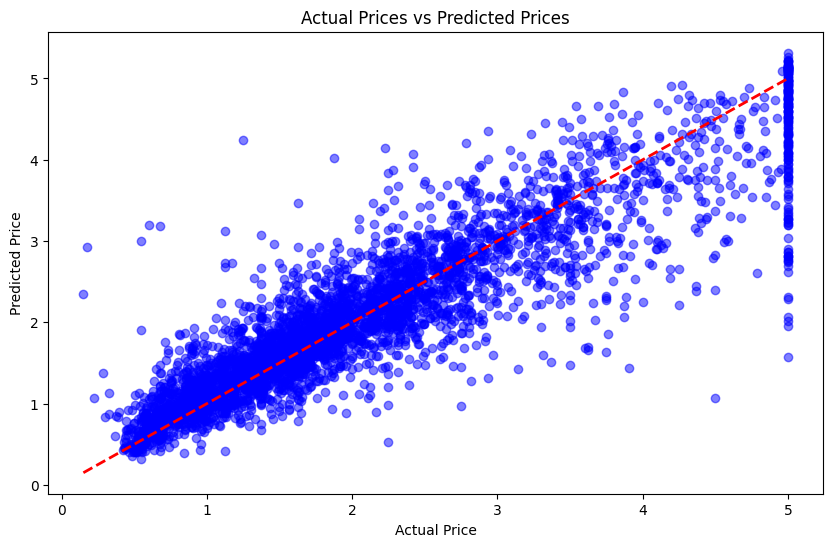

In [6]:
import matplotlib.pyplot as plt

# 1. Metrics ගණනය කිරීම
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
r2 = model.score(X_test, y_test)

print(f"Mean Squared Error: {mse:.4f}")
print(f"Root Mean Squared Error: {rmse:.4f}")
print(f"R-squared Score: {r2:.4f}")

# 2. Visualizing: Actual vs Predicted
plt.figure(figsize=(10, 6))
plt.scatter(y_test, predictions, alpha=0.5, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # 45 degree line
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual Prices vs Predicted Prices')
plt.show()

## 6. Feature Importance (මොඩල් එකේ තීරණ වලට බලපෑ ප්‍රධාන සාධක)

XGBoost මගින් ලබාදෙන වැදගත්ම වාසියක් තමයි **Interpretability**. එනම්, මොඩල් එක වැඩ කරන්නේ "Black Box" එකක් විදියට නෙමෙයි. අපිට පුළුවන් මොන features ද prediction එකට වැඩිපුරම දායක වුණේ කියලා ගණනය කරන්න.

සාමාන්‍යයෙන් XGBoost වල වැදගත්කම මනින ප්‍රධාන ක්‍රම 3ක් තියෙනවා:

1. **Weight:** එම feature එක trees බෙදීමට (Split) භාවිතා වූ වාර ගණන.
2. **Gain (අපි භාවිතා කරන ප්‍රධාන ක්‍රමය):** අදාළ feature එක මගින් මොඩල් එකේ Accuracy එක කොච්චර වැඩි කළාද යන්න. (The average gain of splits which use the feature).
3. **Cover:** එම feature එකට අදාළව කොපමණ දත්ත ප්‍රමාණයක් (Observations) cover වුණාද යන්න.

### ගණිතමය වශයෙන්:
Feature එකක Gain එක වැඩි නම්, ඒ කියන්නේ ඒ feature එක split එකකට පාවිච්චි කළාම "Similarity Score" එකේ ලොකු වැඩිවීමක් වෙලා තියෙනවා කියන එකයි.

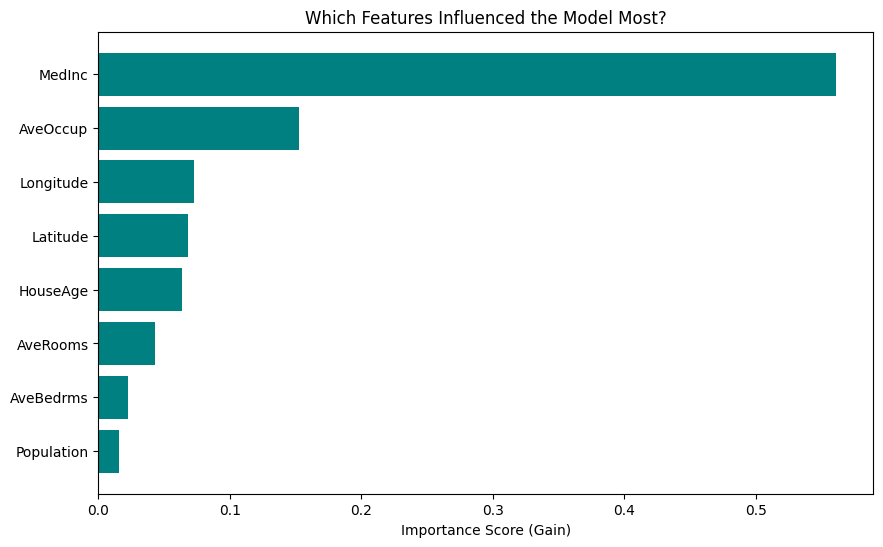

<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

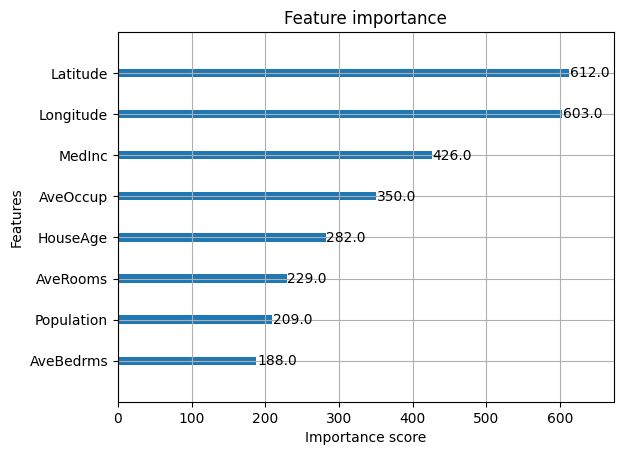

In [ ]:
# 1. Feature Importances ලබා ගැනීම
importances = model.feature_importances_
feature_names = X.columns

# 2. මෙය පහසුවෙන් බලන්න DataFrame එකක් හදමු
feature_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_df = feature_df.sort_values(by='Importance', ascending=True) # අඩු අගයේ සිට වැඩි අගයට

# 3. Graph එක ඇඳීම
plt.figure(figsize=(10, 6))
plt.barh(feature_df['Feature'], feature_df['Importance'], color='teal')
plt.xlabel('Importance Score (Gain)')
plt.title('Which Features Influenced the Model Most?')
plt.show()

# XGBoost වල තියෙන built-in function එකත් පාවිච්චි කරන්න පුළුවන්
xgb.plot_importance(model)